In [1]:
import os
import warnings
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import tensorflow_datasets as tfds

from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import KFold, train_test_split, StratifiedKFold
import src.auxiliar as aux
import src.entropy_estimator as entropy_estimator
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from ucimlrepo import fetch_ucirepo 
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

SMALL_SIZE = 10
MEDIUM_SIZE = 14
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

reds = aux.CustomCmap([60/255,60/255,60/255], [196/255,60/255,60/255])
greens = aux.CustomCmap([0.1, 0.3, 0.1], [0.1, 0.8, 0.1])
blues = aux.CustomCmap([60/255,60/255,60/255], [45/255,159/255,255/255])
teals = aux.CustomCmap([60/255,60/255,60/255], [0/255,200/255,130/255])

class_colors = ['#2D9FFF', '#FF5154', '#E5D352', '#00C882']
model_colors = ['#2D9FFF', '#FF5154', '#E5D352', '#00C882']

metrics = [
	'l1',
    'l2',
	'chebyshev',
	'hamming',
	'canberra',
	'braycurtis',
]

In [2]:
models = [lambda : DecisionTreeClassifier(max_depth=10), 
    	  lambda : RandomForestClassifier(max_depth=5), 
		  lambda : KNeighborsClassifier(),
		  lambda : MLPClassifier(hidden_layer_sizes=[128,64,32], batch_size=32)]
names = ['Decision Tree', 'Random Forest', 'K Neighbors', 'Multilayer Perceptron']
short_name = ['dtc', 'rfc', 'knc', 'mlp']

In [3]:
def estimate(x_data, y_data, export_name, num_models=10, max_neighbors=128):
	with np.errstate(divide='ignore', invalid='ignore'):
		cs = []
		for m in metrics:
			c = entropy_estimator.classificability_estimator(x_data, y_data, k_neighbors=min(max_neighbors, max(int(round(0.01 * len(y_data))),8)), metric=m, num_workers=32)
			cs.append(c)
	os.makedirs('./data/real_world/', exist_ok=True)
	np.save(os.path.join('./data/real_world/', f'{export_name}_limit.npy'), cs)
	with warnings.catch_warnings():
		warnings.filterwarnings("ignore", category=ConvergenceWarning)
		for m, n, sn in zip(models, names, short_name):
			train_accuracy, test_accuracy = [], []
			for i in range(num_models):
				x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.33, random_state=42+i, stratify=y_data)
				clf = m()
				clf = make_pipeline(StandardScaler(), clf)
				clf.fit(x_train, y_train)
				train_score = clf.score(x_train, y_train)
				test_score = clf.score(x_test, y_test)
				train_accuracy.append(train_score)
				test_accuracy.append(test_score)
			np.save(os.path.join('./data/real_world/', f'{export_name}_{sn}_train.npy'), train_accuracy)
			np.save(os.path.join('./data/real_world/', f'{export_name}_{sn}_test.npy'), test_accuracy)

def estimate_limit_only(x_data, y_data, export_name, max_neighbors=128):
	with np.errstate(divide='ignore', invalid='ignore'):
		cs = []
		for m in metrics:
			c = entropy_estimator.classificability_estimator(x_data, y_data, k_neighbors=min(max_neighbors, max(int(round(0.01 * len(y_data))),8)), metric=m, num_workers=32)
			cs.append(c)
	os.makedirs('./data/real_world/', exist_ok=True)
	np.save(os.path.join('./data/real_world/', f'{export_name}_limit.npy'), cs)

def map_string_categories(array):
    import pandas as pd
    array = array.astype(object)
    result = array.copy()
    mappings = []
    for col_idx in range(array.shape[1]):
        column = array[:, col_idx]
        # Detect if the column contains strings or mixed types
        if np.issubdtype(column.dtype, np.object_):
            # Replace NaN values with a placeholder string for processing
            column = np.where(pd.isna(column), "<NaN>", column)
            if all(isinstance(val, str) for val in column):
                # Map unique strings to indices
                unique_values, indices = np.unique(column, return_inverse=True)
                # Replace "<NaN>" with -1 in indices and mappings
                nan_idx = np.where(unique_values == "<NaN>")[0][0] if "<NaN>" in unique_values else None
                if nan_idx is not None:
                    indices[indices == nan_idx] = -1, 'knc', 'mlp'
                    unique_values = np.delete(unique_values, nan_idx)
                # Update result and mappings
                result[:, col_idx] = indices
                mappings.append({i: val for i, val in enumerate(unique_values) if val != "<NaN>"})
            else:
                mappings.append(None)  # Non-string column, skip mapping
        else:
            mappings.append(None)  # Numeric or other non-string column
    return result, mappings

In [ ]:
# Breast Cancer
# Wolberg, W., Mangasarian, O., Street, N., & Street, W. (1993). Breast Cancer Wisconsin (Diagnostic) [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5DW2B.
ds = datasets.load_breast_cancer()
x_data, y_data = ds['data'], ds['target']
estimate(x_data, y_data, 'breast_cancer')

In [ ]:
# Iris
# Fisher, R. (1936). Iris [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C56C76.
ds = datasets.load_iris()
x_data, y_data = ds['data'], ds['target']
estimate(x_data, y_data, 'iris')

In [ ]:
# Digits
# Alpaydin, E. & Kaynak, C. (1998). Optical Recognition of Handwritten Digits [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C50P49.
ds = datasets.load_digits()
x_data, y_data = ds['data'], ds['target']
estimate(x_data, y_data, 'digits')

In [ ]:
# Wine
# Aeberhard, S. & Forina, M. (1992). Wine [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5PC7J.
ds = datasets.load_wine()
x_data, y_data = ds['data'], ds['target']
estimate(x_data, y_data, 'wine')

In [ ]:
# Pima Indians Diabetes Database
ds = np.genfromtxt('./other_datasets/pima.csv', delimiter=',')
x_data, y_data = ds[:,:-1], ds[:,-1].astype(int)
estimate(x_data, y_data, 'pima_diabetes')

In [ ]:
# Sonar, Mines vs. Rocks
# Sejnowski, T. & Gorman, R. (1988). Connectionist Bench (Sonar, Mines vs. Rocks) [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5T01Q.
ds = np.genfromtxt('./other_datasets/sonar.csv', delimiter=',')
x_data, y_data = ds[:,:-1], ds[:,-1].astype(int)
estimate(x_data, y_data, 'sonar')

In [ ]:
# Banknote Authentication
# Lohweg, V. (2012). Banknote Authentication [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55P57.
ds = np.genfromtxt('./other_datasets/bank.csv', delimiter=',')
x_data, y_data = ds[:,:-1], ds[:,-1].astype(int)
estimate(x_data, y_data, 'banknote_authentication')

In [ ]:
# Abalon
# Nash, W., Sellers, T., Talbot, S., Cawthorn, A., & Ford, W. (1994). Abalone [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55C7W.
ds = np.genfromtxt('./other_datasets/abalon.csv', delimiter=',')
x_data, y_data = ds[:,:-1], ds[:,-1].astype(int)
young_mask = y_data <= 11
y_data[young_mask] = 0
y_data[~young_mask] = 1
estimate(x_data, y_data, 'abalon')

In [ ]:
# Ionosphere
# Sigillito, V., Wing, S., Hutton, L., & Baker, K. (1989). Ionosphere [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W01B.
ds = np.genfromtxt('./other_datasets/ionosphere.csv', delimiter=',')
x_data, y_data = ds[:,:-1], ds[:,-1].astype(int)
estimate(x_data, y_data, 'ionosphere')

In [ ]:
# Wheat seeds
# Charytanowicz, M., Niewczas, J., Kulczycki, P., Kowalski, P., & Lukasik, S. (2010). Seeds [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5H30K.
x_datads = np.genfromtxt('./other_datasets/wheat.csv', delimiter=' ')
x_data, y_data = ds[:,:-1], ds[:,-1].astype(int)
estimate(x_data, y_data, 'wheat_seeds')

In [ ]:
# Heart Disease
# Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1989). Heart Disease [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P4X.
ds = fetch_ucirepo(id=45) 
x_data = ds.data.features.to_numpy()
y_data = ds.data.targets.to_numpy().reshape(-1)
x_data = np.where(np.isnan(x_data), -1, x_data)
estimate(x_data, y_data, 'heart_disease')

In [ ]:
# Adult
# Becker, B. & Kohavi, R. (1996). Adult [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20.
ds = fetch_ucirepo(id=2) 
x_data = ds.data.features.to_numpy()
x_data = map_string_categories(x_data)[0]
y_data = ds.data.targets.to_numpy().reshape(-1)
y_data[y_data == '<=50K'] = 0
y_data[y_data == '<=50K.'] = 0
y_data[y_data == '>50K'] = 1
y_data[y_data == '>50K.'] = 1
y_data = y_data.astype(int)
estimate(x_data, y_data, 'adult')

In [ ]:
# Bank Marketing
# Moro, S., Rita, P., & Cortez, P. (2014). Bank Marketing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5K306.
ds = fetch_ucirepo(id=222) 
x_data = ds.data.features.to_numpy()
x_data = map_string_categories(x_data)[0]
y_data = ds.data.targets.to_numpy().reshape(-1)
y_data[y_data == 'no'] = 0
y_data[y_data == 'yes'] = 1
y_data = y_data.astype(int)
estimate(x_data, y_data, 'bank_marketing')

In [ ]:
# Wine Quality
# Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Wine Quality [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C56S3T.
ds = fetch_ucirepo(id=186) 
x_data = ds.data.features.to_numpy()
y_data = ds.data.targets.to_numpy().reshape(-1)
y_data = y_data - np.min(y_data)
estimate(x_data, y_data, 'wine_quality')

In [ ]:
# Student Performance 
# Cortez, P. (2008). Student Performance [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5TG7T.
ds = fetch_ucirepo(id=320) 
x_data = ds.data.features.to_numpy()
x_data = map_string_categories(x_data)[0]
y_data = ds.data.targets.to_numpy()[:,2] # Final grade
excellent_mask = y_data > 15
good_mask = ((y_data >= 14).astype(int) * (y_data <= 15).astype(int)).astype(bool)
satisfactory_mask = ((y_data >= 12).astype(int) * (y_data <= 13).astype(int)).astype(bool)
sufficient_mask = ((y_data >= 10).astype(int) * (y_data <= 11).astype(int)).astype(bool)
fail_mask = y_data < 10
y_data[excellent_mask] = 0
y_data[good_mask] = 1
y_data[satisfactory_mask] = 2
y_data[sufficient_mask] = 3
y_data[fail_mask] = 4
estimate(x_data, y_data, 'student_performance')

In [ ]:
# Car Evaluation
# Bohanec, M. (1988). Car Evaluation [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5JP48.
ds = fetch_ucirepo(id=19) 
x_data = ds.data.features.to_numpy()
x_data[:,0][x_data[:,0] == 'low'] = 0
x_data[:,0][x_data[:,0] == 'med'] = 1
x_data[:,0][x_data[:,0] == 'high'] = 2
x_data[:,0][x_data[:,0] == 'vhigh'] = 3
x_data[:,1][x_data[:,1] == 'low'] = 0
x_data[:,1][x_data[:,1] == 'med'] = 1
x_data[:,1][x_data[:,1] == 'high'] = 2
x_data[:,1][x_data[:,1] == 'vhigh'] = 3
x_data[:,2][x_data[:,2] == '2'] = 0
x_data[:,2][x_data[:,2] == '3'] = 1
x_data[:,2][x_data[:,2] == '4'] = 2
x_data[:,2][x_data[:,2] == '5more'] = 3
x_data[:,3][x_data[:,3] == '2'] = 0
x_data[:,3][x_data[:,3] == '4'] = 1
x_data[:,3][x_data[:,3] == 'more'] = 2
x_data[:,4][x_data[:,4] == 'small'] = 0
x_data[:,4][x_data[:,4] == 'med'] = 1
x_data[:,4][x_data[:,4] == 'big'] = 2
x_data[:,5][x_data[:,5] == 'low'] = 0
x_data[:,5][x_data[:,5] == 'med'] = 1
x_data[:,5][x_data[:,5] == 'high'] = 2
x_data = x_data.astype(int)
y_data = ds.data.targets.to_numpy().reshape(-1)
y_data[y_data == 'unacc'] = 0
y_data[y_data == 'acc'] = 1
y_data[y_data == 'good'] = 2
y_data[y_data == 'vgood'] = 3
y_data = y_data.astype(int)
estimate(x_data, y_data, 'car_evaluation')

In [ ]:
# MNIST dataset
ds = list(tfds.load('mnist', split='train+test'))
x_data = np.array([s['image'].numpy().reshape(-1) for s in ds]) / 255
y_data = np.array([int(s['label']) for s in ds])
scaler = StandardScaler()
x_data = scaler.fit_transform(x_data)

estimate_limit_only(x_data, y_data, 'mnist')

In [ ]:
np.sin(np.pi/4)

In [ ]:
x_data.shape

In [ ]:
np.load('./data/real_world/mnist_limit.npy')

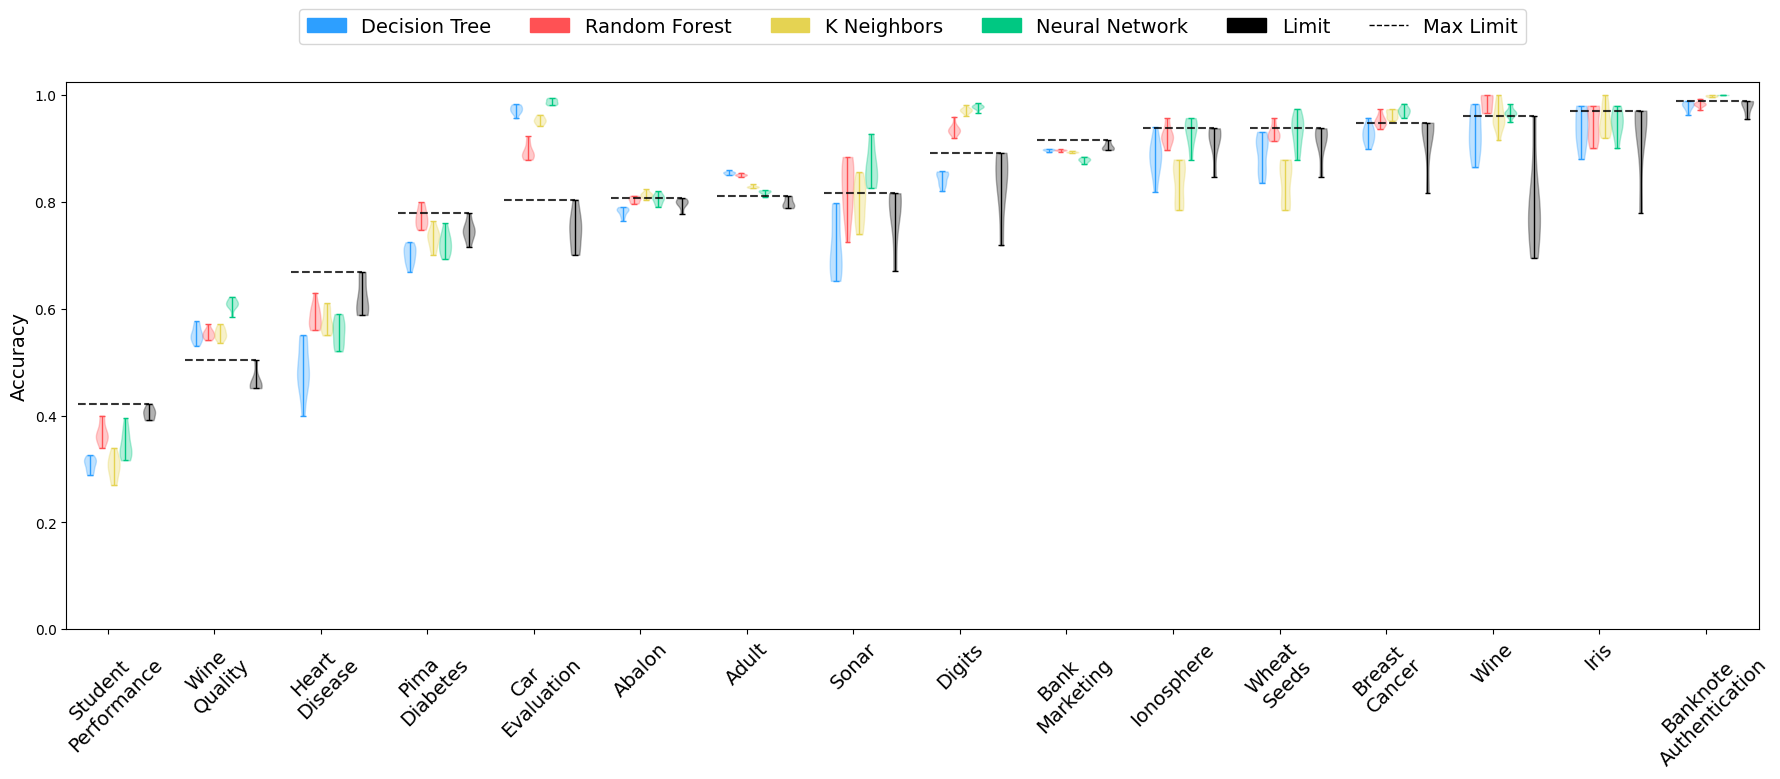

In [17]:
datasets_name = ['Breast\nCancer', 'Iris', 'Digits', 'Wine', 'Pima\nDiabetes', 'Sonar', 'Banknote\nAuthentication', 'Abalon',
            'Ionosphere', 'Wheat\nSeeds', 'Heart\nDisease', 'Adult', 'Bank\nMarketing', 'Wine\nQuality', 'Student\nPerformance', 'Car\nEvaluation']
datasets_path = ['breast_cancer','iris','digits','wine','pima_diabetes','sonar','banknote_authentication','abalon',
                     'ionosphere','wheat_seeds','heart_disease','adult','bank_marketing','wine_quality','student_performance','car_evaluation']

names = ['Decision Tree', 'Random Forest', 'K Neighbors', 'Neural Network']
short_name = ['dtc', 'rfc', 'knc', 'mlp']
x = np.arange(len(datasets_path)) * 9

plt.figure(figsize=(18,8))

limit = []
min_limit = []
metric_name = []
for d in datasets_path:
	l = np.load(os.path.join('./data/real_world/', f'{d}_limit.npy'))
	idx = np.argmax(l)
	limit.append(l[idx])
	metric_name.append(metrics[idx])
	idx = np.argmin(l)
	min_limit.append(l[idx])
limit = np.array(limit)
min_limit = np.array(min_limit)

order = np.argsort(limit)#[::-1]
datasets_name = np.array(datasets_name)[order]
datasets_path = np.array(datasets_path)[order]

legend_elements = []
for i, (n, sn, c) in enumerate(zip(names, short_name, model_colors)):
	accuracies = []
	for d in datasets_path:
		test_accuracy = np.load(os.path.join('./data/real_world/', f'{d}_{sn}_test.npy'))
		accuracies.append(list(test_accuracy))
	parts = plt.violinplot(accuracies, positions=x+i, widths=1)
	for pc in parts['bodies']:
		pc.set_facecolor(c)
		pc.set_edgecolor(c)
		pc.set_alpha(0.3)
	for partname in ('cbars','cmins','cmaxes'):
		vp = parts[partname]
		vp.set_edgecolor(c)
		vp.set_linewidth(1)
	legend_elements.append(Patch(facecolor=c, edgecolor=c, label=n))


#legend_elements = []
limits = []
c = 'k'
for d in datasets_path:
	test_accuracy = np.load(os.path.join('./data/real_world/', f'{d}_limit.npy'))
	limits.append(list(test_accuracy))
parts = plt.violinplot(limits, positions=x+5, widths=1)
for pc in parts['bodies']:
	pc.set_facecolor(c)
	pc.set_edgecolor(c)
	pc.set_alpha(0.3)
for partname in ('cbars','cmins','cmaxes'):
	vp = parts[partname]
	vp.set_edgecolor(c)
	vp.set_linewidth(1)
legend_elements.append(Patch(facecolor=c, edgecolor=c, label='Limit'))

for i in range(len(limit)):
	plt.plot([x[i]-1, x[i]+5], [limit[order][i], limit[order][i]], 'k--', alpha=0.8)
#	plt.text(x[i]+2, min_limit[order][i]-0.1, metric_name[i], rotation=0, va='top', ha='center')
legend_elements.append(Line2D([0], [0], color='k', lw=1, linestyle='--', label='Max Limit'))


plt.xticks(x+1.5, datasets_name, rotation=45, fontsize=MEDIUM_SIZE)
plt.legend(handles=legend_elements, ncols=6, bbox_to_anchor=(0.5, 1.15), loc='upper center', fontsize=MEDIUM_SIZE)
plt.ylim(0,1.025)
plt.xlim(x[0]-2, x[-1]+6)
plt.ylabel('Accuracy')

plt.tight_layout()
plt.savefig('./images/real_world_datasets.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
limit.shape

(16,)